# Data Loading & Inspection


In [1]:
import os
from google.colab import files

# Simply upload the CSV manually to avoid Kaggle API/JSON errors
if not os.path.exists('netflix_titles.csv'):
    print("Please upload the 'netflix_titles.csv' file from your computer:")
    uploaded = files.upload()
else:
    print("'netflix_titles.csv' is already present in the environment.")


Please upload the 'netflix_titles.csv' file from your computer:


Saving netflix_titles.csv to netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Read the CSV file into a pandas DataFrame.
# pd.read_csv() loads tabular data from a comma-separated values file into a DataFrame object.
df = pd.read_csv('netflix_titles.csv')

# Print the shape (number of rows and columns) of the DataFrame.
# .shape is an attribute that returns a tuple representing the dimensionality of the DataFrame.
print("Shape of the dataset:", df.shape)
print("\n---")

# Print the data types of each column.
# .dtypes is an attribute that returns a Series with the data type of each column.
print("\nData Types:\n", df.dtypes)
print("\n---")

# Print a concise summary of the DataFrame, including the index dtype, column dtypes, non-null values and memory usage.
# .info() provides a quick overview of the dataset.
print("\nDataFrame Info:")
df.info()
print("\n---")

# Print the number of missing (NaN/null) values in each column.
# .isnull() returns a DataFrame of the same shape with boolean values indicating missing data.
# .sum() calculates the sum of True values (which are treated as 1) for each column.
print("\nMissing values per column:\n", df.isnull().sum())
print("\n---")

# Print the number of exact duplicate rows in the DataFrame.
# .duplicated() returns a boolean Series denoting duplicate rows.
# .sum() counts the total number of duplicates.
print("\nDuplicate row count (full row):", df.duplicated().sum())
print("Duplicate row count (subset=['title', 'director', 'country', 'release_year']):", df.duplicated(subset=['title', 'director', 'country', 'release_year']).sum())


Shape of the dataset: (8807, 12)

---

Data Types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

---

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 n

**Dataset Summary:**
This dataset contains listings of movies and TV shows available on Netflix, including details like cast, directors, ratings, release year, duration, and genres.
The data includes multiple columns of mixed types, such as text, dates, and categorical variables.
We can observe missing values in several columns like 'director', 'cast', and 'country', which are common in real-world entertainment datasets.
'date_added' needs to be converted to a proper datetime format for time-based analysis.
Overall, this dataset provides a rich foundation for analyzing Netflix's content strategy and identifying trends in media production over time.


# Data Cleaning
**Handling Missing Values & Cleaning Steps Reasoning:**
- **director**: We have many missing values. Dropping these rows would result in significant data loss. We will fill missing values with 'Unknown'.
- **cast**: Similar to director, dropping isn't ideal. We'll fill with 'Unknown'.
- **country**: We will fill missing values with 'Unknown' to avoid skewing data heavily if many are missing.
- **date_added**: A small number might be missing. We will drop the rows where 'date_added' is missing because we need dates for trend analysis.
- **rating**: Very few missing. We can fill them with 'Unknown'.
- **show_id, description**: We will drop the 'description' column as natural language processing is outside our current scope. 'show_id' is just an identifier, so we drop it to focus on analytical features.


In [3]:
# Drop 'show_id' and 'description' columns as they are not needed for our current numerical/categorical analysis.
# .drop() removes specified labels from rows or columns. axis=1 specifies we are dropping columns.
# inplace=True modifies the DataFrame directly without returning a new one.
df.drop(['show_id', 'description'], axis=1, inplace=True)

# Fill missing values in 'director', 'cast', 'country', and 'rating' with the string 'Unknown'.
# .fillna() replaces NA/NaN values with a specified value.
fill_cols = ['director', 'cast', 'country', 'rating']
df[fill_cols] = df[fill_cols].fillna('Unknown')

# Drop rows where 'date_added' is missing (NaN).
# .dropna() removes missing values. subset specifies which columns to consider.
initial_rows = len(df)
df.dropna(subset=['date_added'], inplace=True)
final_rows = len(df)
lost_rows = initial_rows - final_rows
print(f"Dropped {lost_rows} rows due to missing 'date_added'. Data lost: {(lost_rows/initial_rows)*100:.2f}%")

# Remove leading and trailing whitespace from the 'date_added' column to ensure clean parsing.
# .str is an accessor to apply string methods. .strip() removes whitespace from both ends.
df['date_added'] = df['date_added'].str.strip()

# Convert the 'date_added' column to datetime objects.
# pd.to_datetime() converts an argument to datetime.
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract just the year from the 'date_added' column to a new column for easier grouping later.
# .dt is an accessor for datetime properties. .year extracts the year.
df['year_added'] = df['date_added'].dt.year

# Remove duplicate rows from the DataFrame.
# .drop_duplicates() removes duplicate rows.
df.drop_duplicates(inplace=True)

# Verify the changes by printing the sum of missing values again.
print("Remaining missing values:\n", df.isnull().sum())


Dropped 10 rows due to missing 'date_added'. Data lost: 0.11%
Remaining missing values:
 type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
year_added      0
dtype: int64


# Exploratory Data Analysis — 5 Questions


## a. What is the ratio of Movies to TV Shows?


In [4]:
# Count the occurrences of each unique value in the 'type' column.
# .value_counts() returns a Series containing counts of unique values in descending order.
type_counts = df['type'].value_counts()
print("Count of Movies and TV Shows:\n", type_counts)

# Calculate the ratio (percentage) of Movies vs TV Shows.
# normalize=True returns proportions instead of frequencies.
type_ratio = df['type'].value_counts(normalize=True) * 100
print("\nRatio of Movies vs TV Shows (%):\n", type_ratio)


Count of Movies and TV Shows:
 type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Ratio of Movies vs TV Shows (%):
 type
Movie      69.694214
TV Show    30.305786
Name: proportion, dtype: float64


## b. Which countries produce the most content?


In [5]:
# The 'country' column can contain multiple countries separated by commas.
# We take the first country before the comma as the primary country.
# .apply() invokes a function on values of Series. lambda creates an anonymous function.
# .split(',')[0] splits the string by comma and takes the first element.
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0])

# Count content by primary country and get the top 10.
# .head(10) returns the first 10 rows of the Series.
top_countries = df['primary_country'].value_counts().head(10)
print("Top 10 content-producing countries:\n", top_countries)


Top 10 content-producing countries:
 primary_country
United States     3205
India             1008
Unknown            830
United Kingdom     627
Canada             271
Japan              258
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64


## c. What are the top 10 most common genres (listed_in)?


In [6]:
# The 'listed_in' column contains genres separated by commas.
# We will split these strings into lists, then explode the lists into separate rows to count individual genres.
# .assign() assigns new columns to a DataFrame.
# .str.split(', ') splits the string into a list of strings based on the delimiter.
# .explode() transforms each element of a list-like to a row, replicating index values.
genres_exploded = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')

# Count the occurrences of each unique genre.
top_genres = genres_exploded['genre'].value_counts().head(10)
print("Top 10 most common genres:\n", top_genres)


Top 10 most common genres:
 genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


## d. How has content added to Netflix trended by year (date_added)?


In [7]:
# Group the data by 'year_added' and count the number of titles added each year.
# .groupby() groups DataFrame using a mapper or by a Series of columns.
# .size() returns the number of elements in the underlying data for each group.
# .reset_index(name='count') resets the index and renames the resulting count column.
yearly_trend = df.groupby('year_added').size().reset_index(name='count')

# Display the trend data for the last 10 years available in the dataset.
# .tail(10) returns the last 10 rows.
print("Titles added per year (Last 10 years):\n", yearly_trend.tail(10))


Titles added per year (Last 10 years):
     year_added  count
4         2012      3
5         2013     11
6         2014     24
7         2015     82
8         2016    429
9         2017   1188
10        2018   1649
11        2019   2016
12        2020   1879
13        2021   1498


## e. What is the distribution of content ratings (rating column)?


In [8]:
# Count the frequencies of each rating value.
rating_distribution = df['rating'].value_counts()
print("Distribution of content ratings:\n", rating_distribution)

# Provide descriptive statistics for the numerical 'release_year' column as an extra step.
# .describe() generates descriptive statistics that summarize the central tendency, dispersion and shape of a dataset’s distribution.
print("\nDescriptive stats for release_year:\n", df['release_year'].describe())


Distribution of content ratings:
 rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
Name: count, dtype: int64

Descriptive stats for release_year:
 count    8797.000000
mean     2014.183472
std         8.822191
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


# Visualizations — Minimum 6 Charts


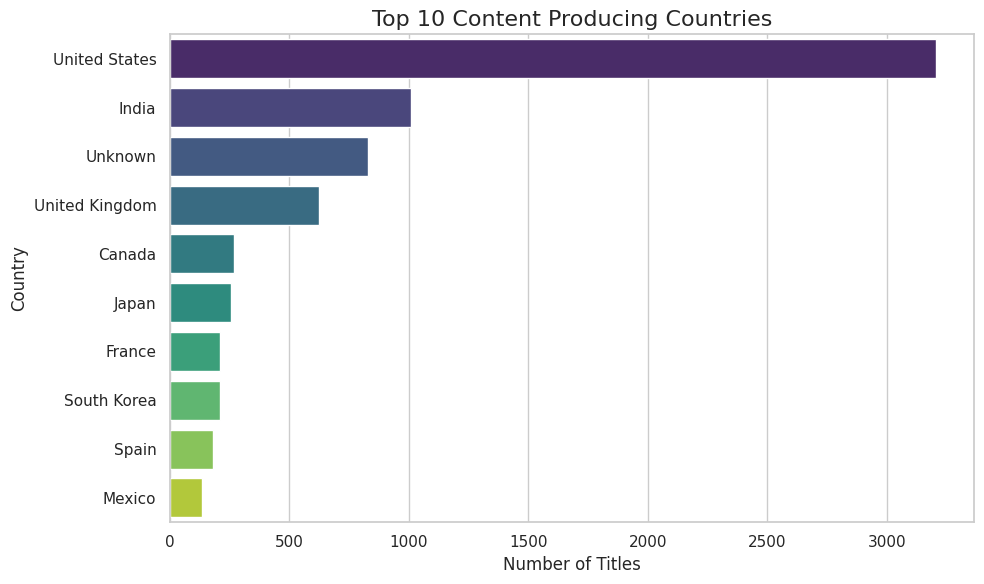

In [9]:
# Set the plotting style using seaborn.
# sns.set_theme() sets the aesthetic style of the plots.
sns.set_theme(style="whitegrid")

# 1. Bar chart: content count by country (top 10)
# plt.figure() creates a new figure with a specific size (width, height) in inches.
plt.figure(figsize=(10, 6))

# sns.barplot() shows point estimates and confidence intervals as rectangular bars.
# We pass the index (country names) as x and values (counts) as y.
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Content Producing Countries", fontsize=16) # plt.title() sets the title.
plt.xlabel("Number of Titles", fontsize=12) # plt.xlabel() sets the x-axis label.
plt.ylabel("Country", fontsize=12) # plt.ylabel() sets the y-axis label.
plt.tight_layout() # plt.tight_layout() adjusts subplot parameters to give specified padding.
plt.show() # plt.show() displays the figure.


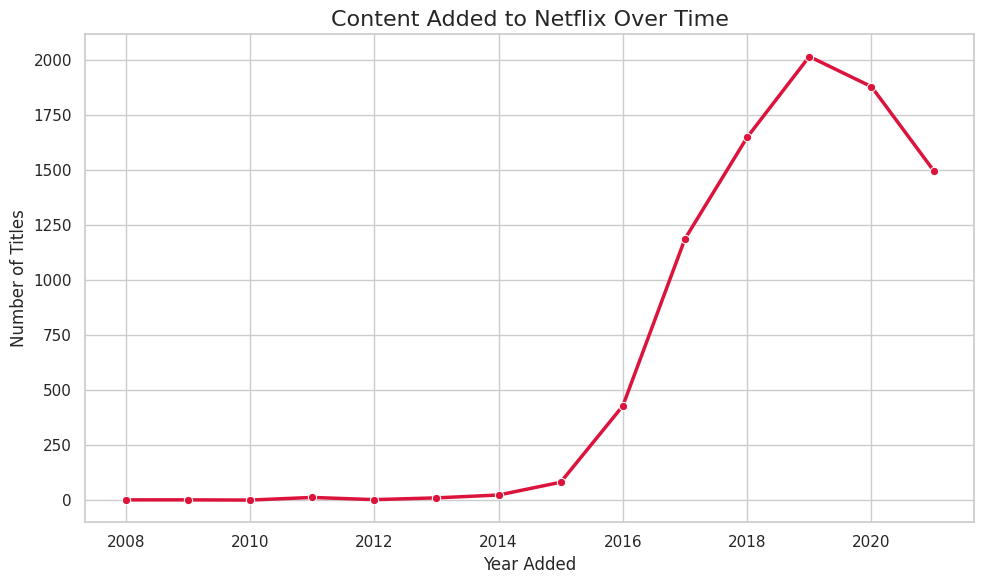

In [10]:
# 2. Line chart: titles added per year over time
plt.figure(figsize=(10, 6))

# sns.lineplot() draws a line plot with possibility of several semantic groupings.
sns.lineplot(data=yearly_trend, x='year_added', y='count', marker='o', linewidth=2.5, color='crimson')
plt.title("Content Added to Netflix Over Time", fontsize=16)
plt.xlabel("Year Added", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)
# Ensure x-axis ticks are integers (years) by passing an array of ticks
plt.xticks(np.arange(yearly_trend['year_added'].min(), yearly_trend['year_added'].max()+1, 2))
plt.tight_layout()
plt.show()


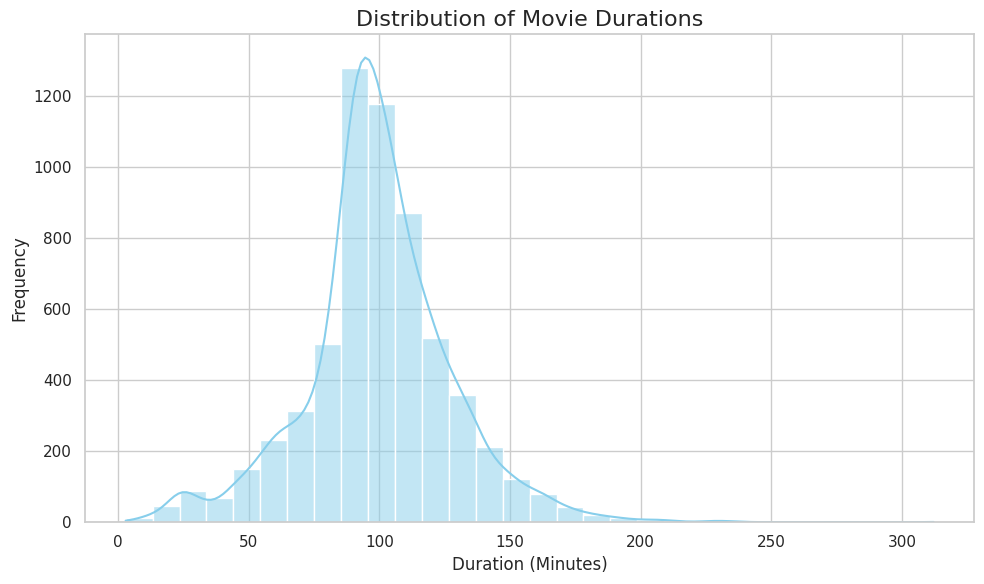

In [11]:
# 3. Histogram: distribution of movie durations
# First, filter the dataframe for Movies and extract the numerical duration.
movies_df = df[df['type'] == 'Movie'].copy()

# The 'duration' column has format like '90 min'. We extract the number and convert to float.
# .str.extract() extracts capture groups in the regex as columns in a DataFrame. (\d+) captures digits.
# .astype(float) casts a pandas object to a specified dtype.
movies_df['duration_min'] = movies_df['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10, 6))
# sns.histplot() plots univariate or bivariate histograms to show distributions of datasets.
# bins specifies the number of histogram bins. kde=True adds a Kernel Density Estimate plot.
sns.histplot(movies_df['duration_min'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Movie Durations", fontsize=16)
plt.xlabel("Duration (Minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


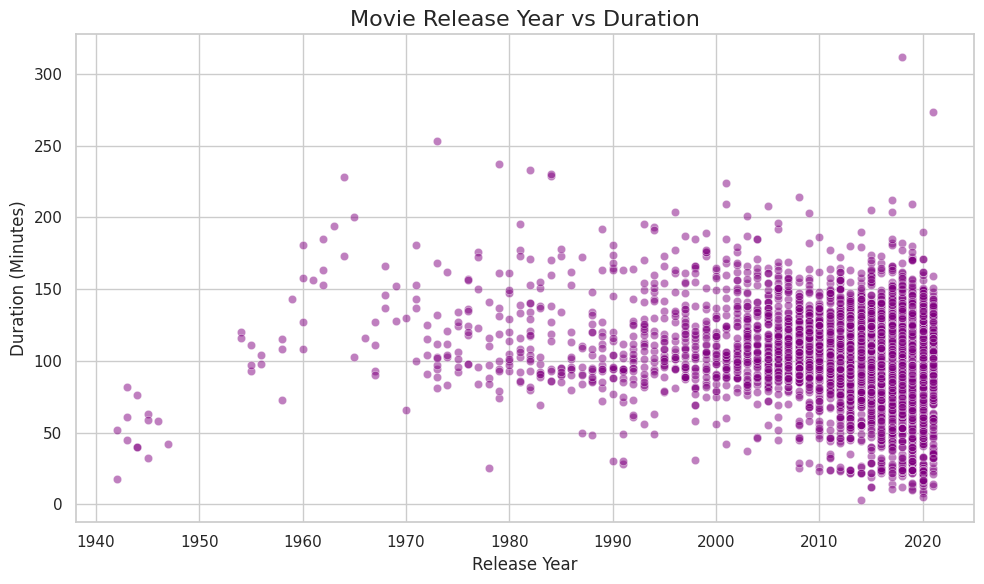

In [12]:
# 4. Scatter plot: release_year vs duration_min for Movies only
plt.figure(figsize=(10, 6))

# Extract movies and drop NaN durations to avoid plotting issues
movies_duration = movies_df.dropna(subset=['duration_min'])

# sns.scatterplot() draws a scatter plot with possibility of several semantic groupings.
# alpha sets the transparency of the points to handle overplotting.
sns.scatterplot(data=movies_duration, x='release_year', y='duration_min', alpha=0.5, color='purple')
plt.title("Movie Release Year vs Duration", fontsize=16)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Duration (Minutes)", fontsize=12)
plt.tight_layout()
plt.show()

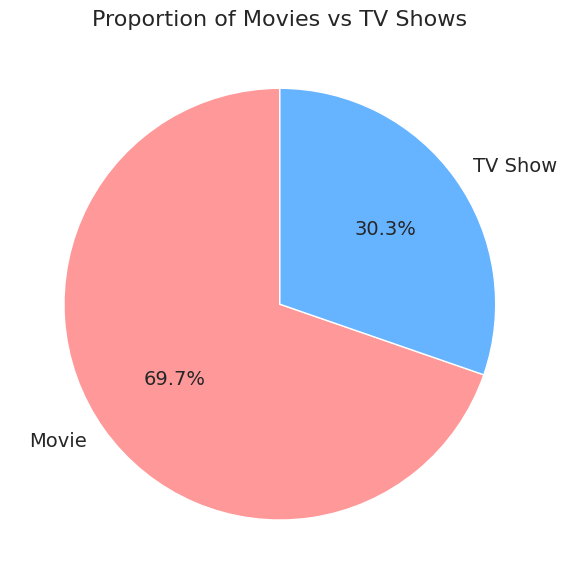

In [13]:
# 5. Pie chart: Movie vs TV Show proportion
plt.figure(figsize=(10, 6))

# Define colors for the pie slices
colors = ['#ff9999','#66b3ff']

# plt.pie() plots a pie chart.
# autopct formats the numerical value (percentage) on each slice.
# startangle rotates the start of the pie chart by given degrees counterclockwise from the x-axis.
plt.pie(type_counts, labels=type_counts.index, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 14})
plt.title("Proportion of Movies vs TV Shows", fontsize=16)
plt.tight_layout()
plt.show()


Initial crosstab shape: (10, 15)
Genre axis > 8, reducing to top 5 genres.
Rating axis > 8, reducing to top 8 most frequent ratings.
New crosstab shape after reduction: (5, 8)


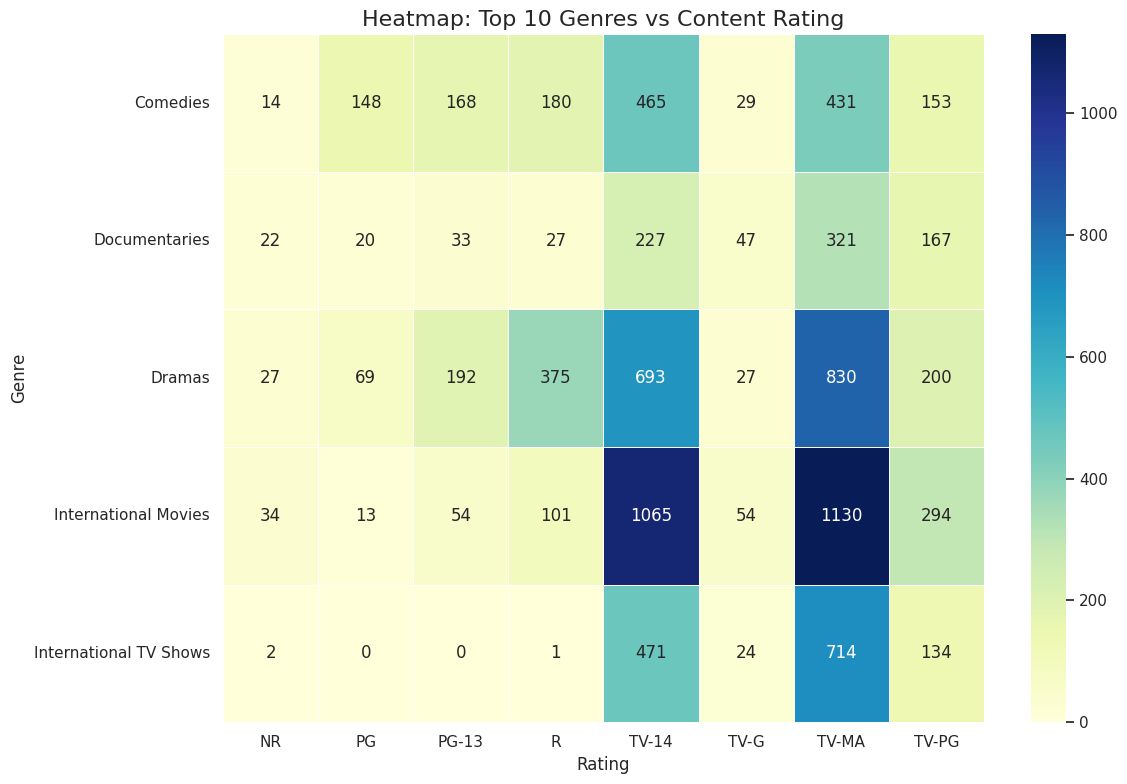

In [14]:
# 6. Heatmap: genre-by-rating crosstab heatmap
plt.figure(figsize=(12, 8))

# Create a cross-tabulation of top 10 genres and all ratings.
# pd.crosstab() computes a simple cross tabulation of two (or more) factors.
# We use the 'genres_exploded' dataframe from earlier.
top_genres_list = top_genres.index.tolist()
# Filter for only the top genres
genre_rating_df = genres_exploded[genres_exploded['genre'].isin(top_genres_list)]

# Generate the crosstab
crosstab = pd.crosstab(genre_rating_df['genre'], genre_rating_df['rating'])

print("Initial crosstab shape:", crosstab.shape)

# Check axes independently
reduced_genre = False
reduced_rating = False

if crosstab.shape[0] > 8:
    print("Genre axis > 8, reducing to top 5 genres.")
    top_5_genres_list = top_genres.head(5).index.tolist()
    genre_rating_df = genre_rating_df[genre_rating_df['genre'].isin(top_5_genres_list)]
    reduced_genre = True

if crosstab.shape[1] > 8:
    print("Rating axis > 8, reducing to top 8 most frequent ratings.")
    top_8_ratings = genre_rating_df['rating'].value_counts().head(8).index.tolist()
    genre_rating_df = genre_rating_df[genre_rating_df['rating'].isin(top_8_ratings)]
    reduced_rating = True

if reduced_genre or reduced_rating:
    crosstab = pd.crosstab(genre_rating_df['genre'], genre_rating_df['rating'])
    print("New crosstab shape after reduction:", crosstab.shape)

# sns.heatmap() plots rectangular data as a color-encoded matrix.
# cmap specifies the colormap. annot=True writes the data value in each cell. fmt='d' formats annotations as integers.
sns.heatmap(crosstab, cmap="YlGnBu", annot=True, fmt='d', linewidths=.5)
plt.title("Heatmap: Top 10 Genres vs Content Rating", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()


# Insights Report

1. [TODO: fill in after reviewing output] — based on the proportion of Movies vs TV Shows pie chart.
2. [TODO: fill in after reviewing output] — based on the top 10 content producing countries bar chart.
3. [TODO: fill in after reviewing output] — based on the trend of titles added per year line chart.
4. [TODO: fill in after reviewing output] — based on the distribution of movie durations histogram.
5. [TODO: fill in after reviewing output] — based on the genres vs ratings heatmap.


# Reflection

Most surprising finding: [TODO - write 3-5 lines]
